# Data exploration of precursors dataset

Loading data into DataFrame

In [211]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

path = "../local/Tvarminne/CIApi_data/MION_NO3_WinterSchool.csv"

df = pd.read_csv(path, engine="pyarrow")
df["Time"] = pd.to_datetime(df["Time"], format="%d-%b-%Y %H:%M:%S", errors='coerce')
df.set_index("Time", inplace=True)

Exploring first few rows of the data

In [212]:
print(df.head())

                     Reagents        SA         IA   Monomers  \
Time                                                            
2024-01-01 00:49:36  19187.32  266274.1  1376.2510  1670592.0   
2024-01-01 00:54:00  19790.46  364630.1  8150.7040  2240774.0   
2024-01-01 01:00:00  19629.35  312883.7  4079.2690  2172053.0   
2024-01-01 01:48:00  15148.97  371931.5   299.1059  1465145.0   
2024-01-01 01:54:00  15987.85  362870.5  2687.6250  1776612.0   

                     NitrogenMonomers     Dimers  NitrogenDimers  \
Time                                                               
2024-01-01 00:49:36         1001643.0  147410.30        40262.84   
2024-01-01 00:54:00         1063855.0  130373.20        55648.84   
2024-01-01 01:00:00         1303544.0   81801.68        46439.79   
2024-01-01 01:48:00          828609.1  126698.50        40902.90   
2024-01-01 01:54:00         1029344.0  149010.60        46042.23   

                     TotalOrganics  
Time                          

Exploring basic properties of each column

In [213]:
print(df.describe())

           Reagents            SA            IA      Monomers  \
count  66183.000000  6.618300e+04  6.618300e+04  6.618300e+04   
mean   17506.064321  1.066824e+06  1.148194e+06  1.356784e+07   
std     5684.322021  2.692059e+06  6.068575e+06  1.528804e+07   
min        7.456126  0.000000e+00  0.000000e+00  2.461165e+05   
25%    14119.865000  5.541019e+04  4.067285e+04  4.610562e+06   
50%    17768.450000  1.773352e+05  1.697911e+05  8.750981e+06   
75%    21565.685000  7.979227e+05  8.192583e+05  1.717991e+07   
max    37903.140000  6.544866e+07  5.374306e+08  6.211909e+08   

       NitrogenMonomers        Dimers  NitrogenDimers  TotalOrganics  
count      6.618300e+04  6.618300e+04    6.618300e+04   6.618300e+04  
mean       2.134246e+07  3.614300e+06    9.773323e+05   3.272853e+08  
std        2.431438e+07  7.771448e+07    1.490151e+07   6.627985e+08  
min        0.000000e+00  0.000000e+00    0.000000e+00   2.274554e+07  
25%        4.677180e+06  2.315839e+05    6.582056e+04   1.2

Verifying there are no missing values

In [214]:
print(df.isnull().sum())

Reagents            0
SA                  0
IA                  0
Monomers            0
NitrogenMonomers    0
Dimers              0
NitrogenDimers      0
TotalOrganics       0
dtype: int64


Exploring correlation

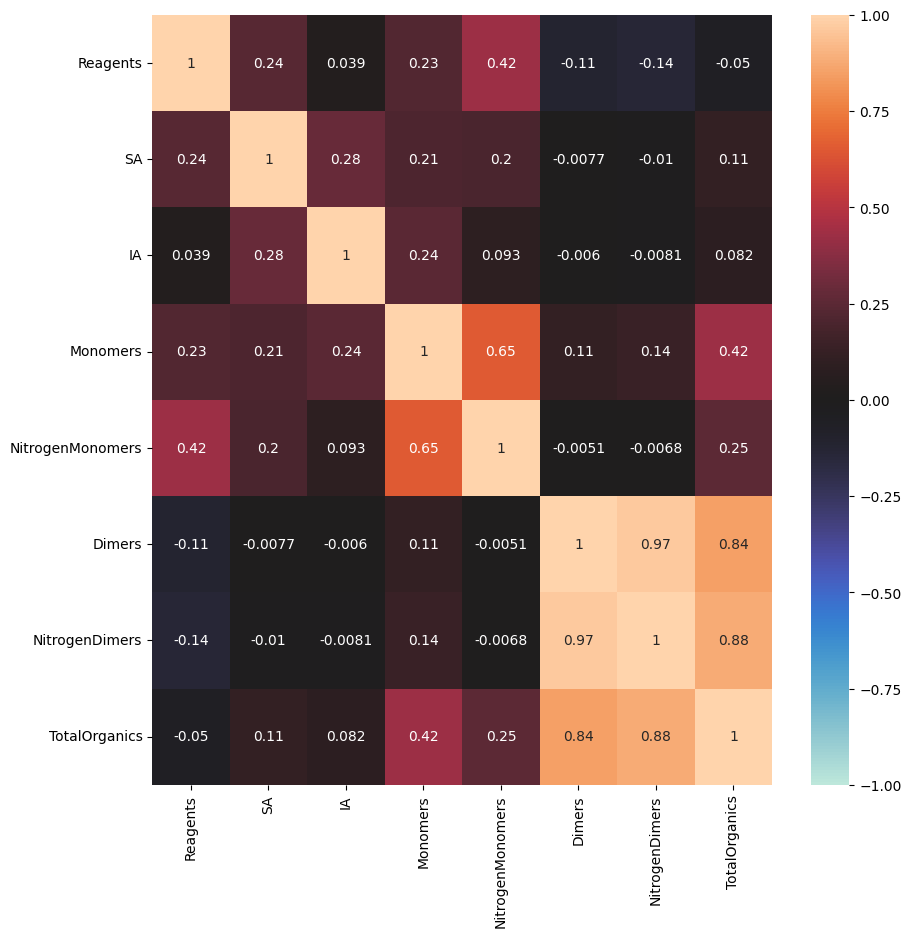

In [215]:
plt.figure(figsize=(10,10))
sns.heatmap(
        df.corr(),
        annot=True,
        vmin=-1, vmax=1, center=0, 
        xticklabels=1, 
        yticklabels=1)
plt.show()

Removing outliers

In [216]:
DATA_MAX = {
    "IA": 0.6e8
} 

window = 300
threshold = 3

for col in df.columns:
    max_value = DATA_MAX.get(col, None)
    if max_value is not None:
        df[col] = df[col].clip(upper=max_value)

    rolling_mean = df[col].rolling(window=window, center=True).mean()
    rolling_std = df[col].rolling(window=window, center=True).std()
    z_score = (df[col] - rolling_mean) / rolling_std
    outliers = z_score.abs() > threshold
    print(f"Column: {col}, Outliers detected: {outliers.sum()}")
    df.loc[outliers, col] = np.nan

Column: Reagents, Outliers detected: 325
Column: SA, Outliers detected: 1452
Column: IA, Outliers detected: 1086
Column: Monomers, Outliers detected: 520
Column: NitrogenMonomers, Outliers detected: 528
Column: Dimers, Outliers detected: 1155
Column: NitrogenDimers, Outliers detected: 1061
Column: TotalOrganics, Outliers detected: 290


TODO: remove first line, remove outlier in second one to see iodic acid peak in summer

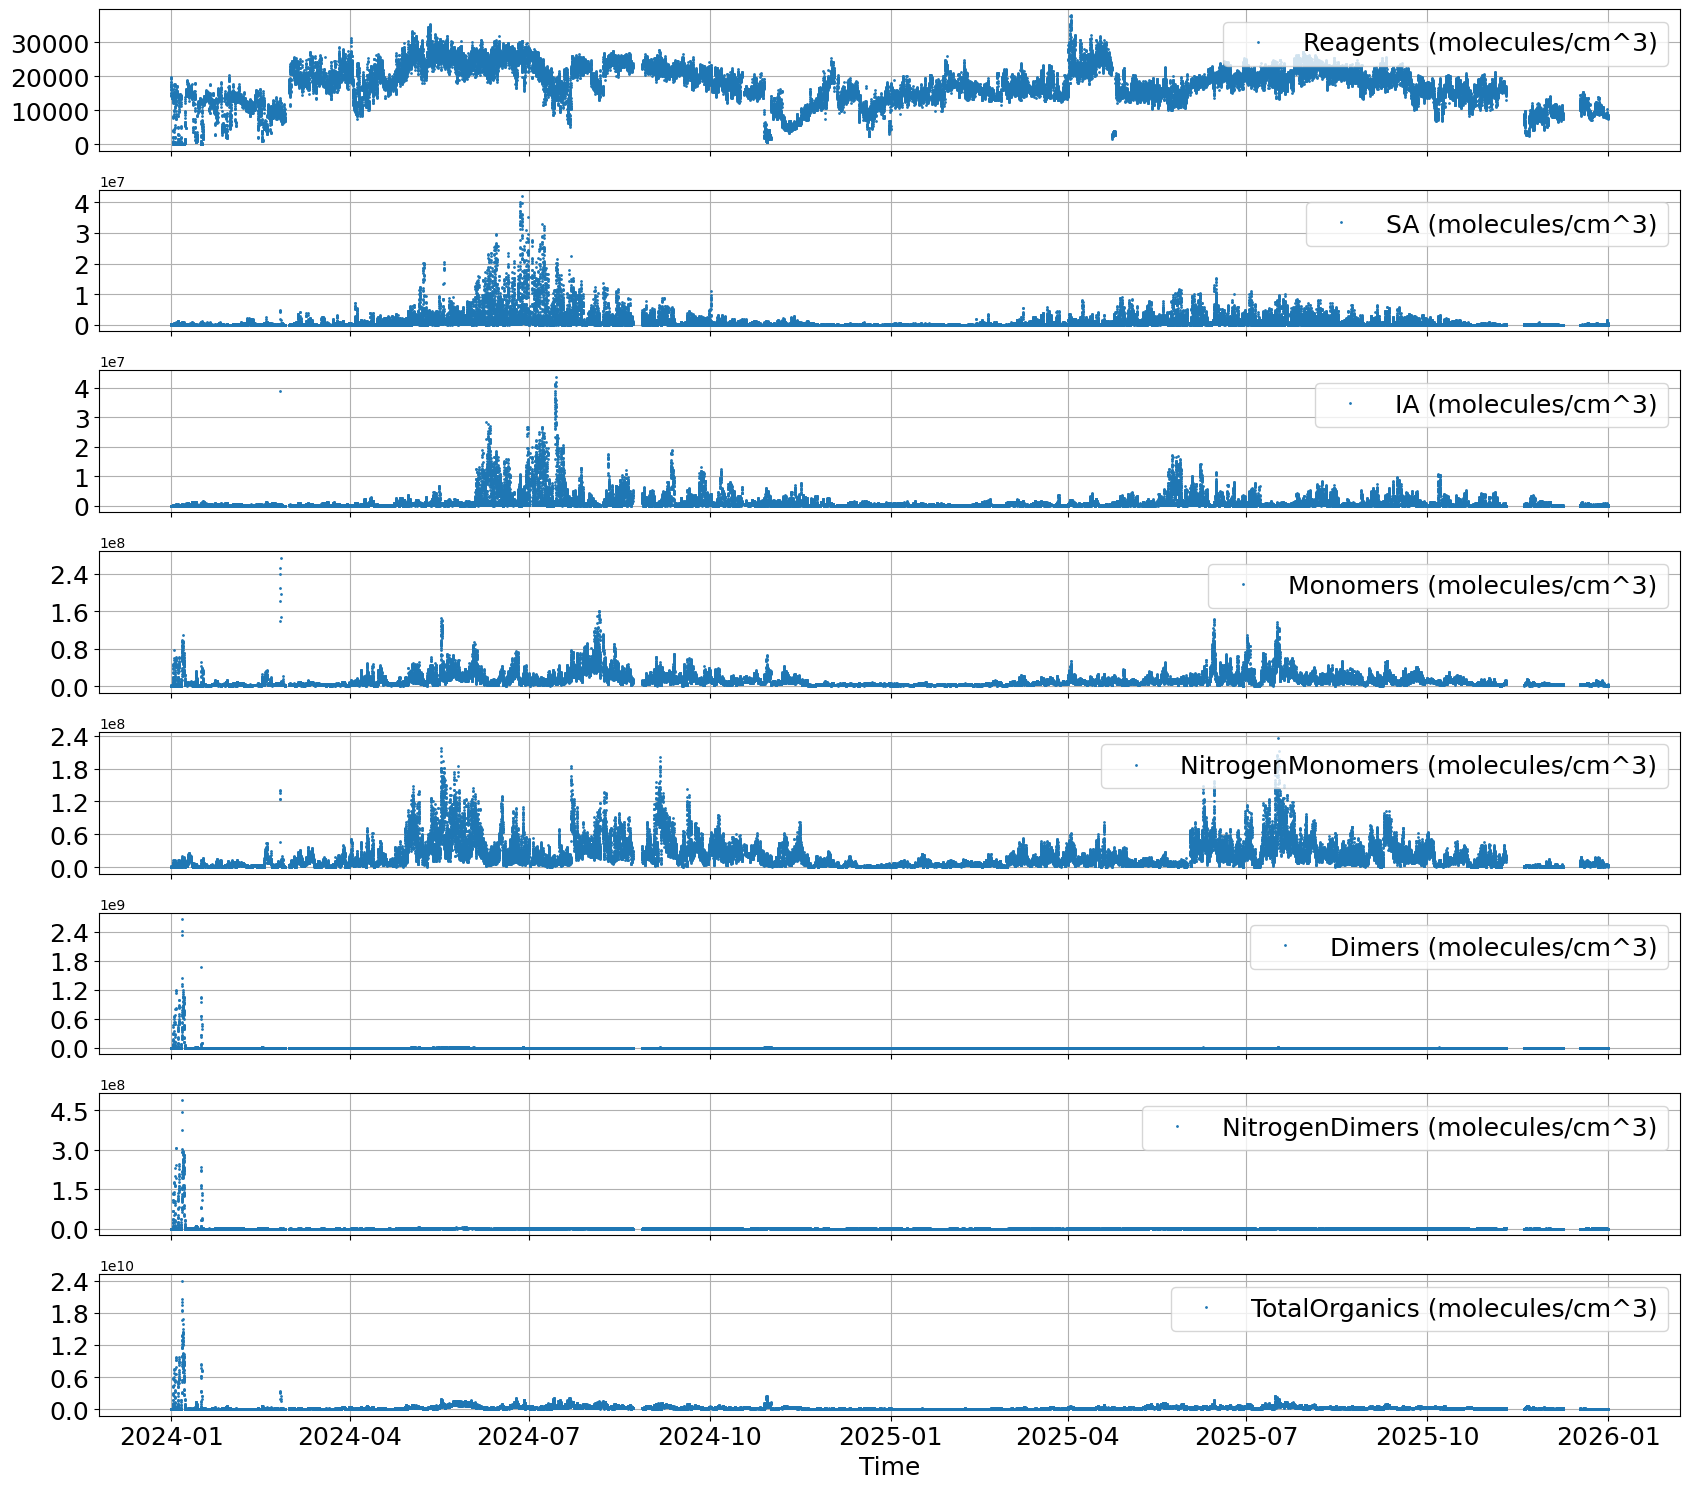

In [217]:
fig, axes = plt.subplots(
    len(df.columns),
    1,
    figsize=(17, 15),
    sharex=True
)

# fig.suptitle("Precursors")

for idx, value in enumerate(df.columns):
    ax = axes[idx]
    ax.plot(df.index, df[value], label=f"{value} (molecules/cm^3)", marker='o', markersize=1, linestyle='None')
    ax.legend(loc="upper right", fontsize=18)
    ax.grid(True)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.tick_params(axis='both', labelsize=18)
    # ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}"))
plt.xlabel("Time", fontsize=18)
plt.tight_layout()
plt.show()